Nom : 
- AGBOSSOU SESSOU Hola Anne-Stéphanie
- DUEVI-TSIBIAKU koko Bertille

Filère : IA et Big Data

# Etape 1 : Chargement des données

In [28]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


Étape 1 : Chargement des données

In [29]:
def load_data(file_path : str):
    return pd.read_csv(file_path)

In [30]:
print("Aperçu des données :")

df_transaction = load_data('transactions.csv')
df_transaction.head()
df_transaction.info()

Aperçu des données :
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   global_id        20000 non-null  int64  
 1   sender_id        20000 non-null  int64  
 2   receiver_id      20000 non-null  int64  
 3   initial_amount   20000 non-null  float64
 4   transfer_amount  20000 non-null  float64
 5   amount_received  20000 non-null  float64
 6   final_amount     20000 non-null  float64
 7   date             20000 non-null  str    
dtypes: float64(4), int64(3), str(1)
memory usage: 1.2 MB


In [31]:

# Exploration des données 

def plot_histograms(df):
    df.hist(figsize=(12, 8), bins=50)
    plt.suptitle("Distribution des variables")
    plt.show()
    
    
def plot_scatter(df):
    plt.figure(figsize=(8, 6))

    plt.scatter(df["transfer_amount"], df["amount_received"], alpha=0.5)

    plt.xlabel("Transfer amount")
    plt.ylabel("Amount received")
    plt.title("Relation transfert vs réception")

    plt.show()
    
    
def plot_boxplots(df):
    plt.figure(figsize=(12, 6))

    sns.boxplot(data=df)

    plt.title("Détection visuelle des outliers")
    plt.xticks(rotation=45)

    plt.show()

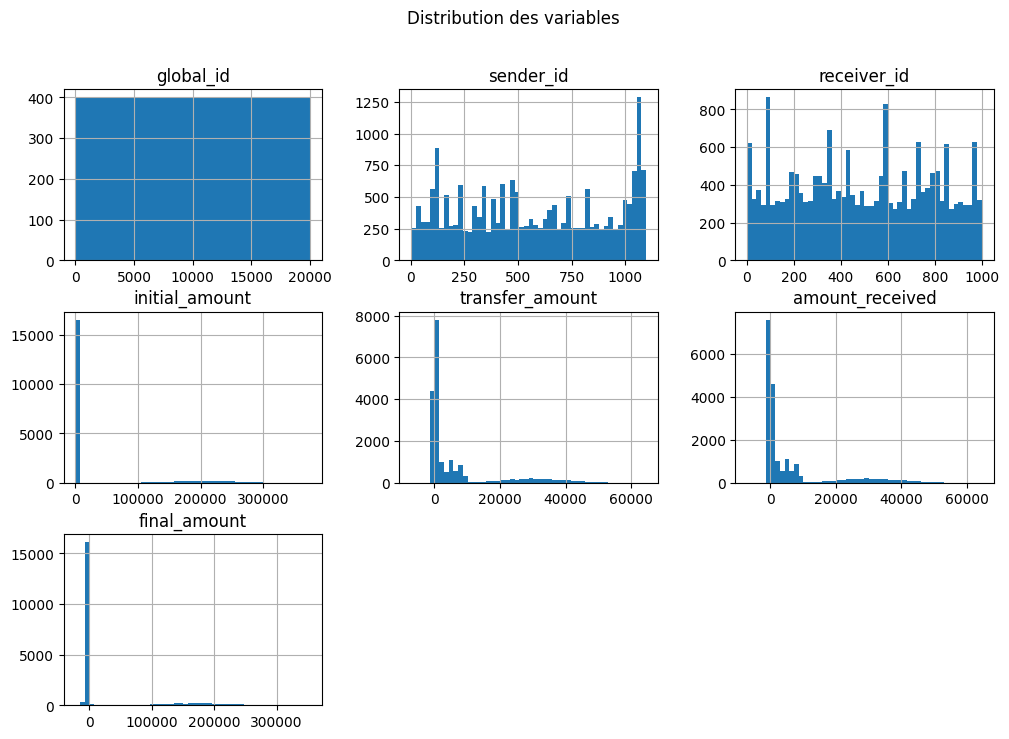

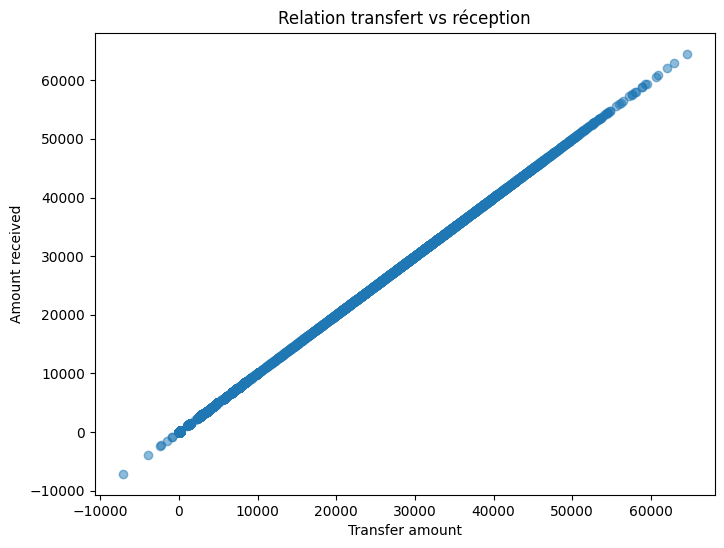

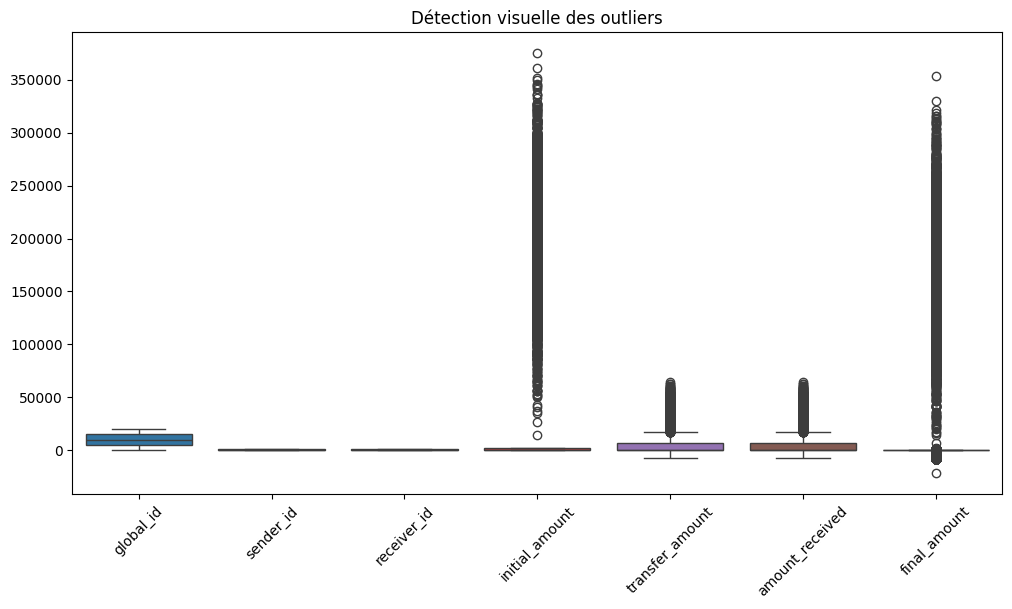

In [21]:
histogram = plot_histograms(df_transaction)

nuage_point = plot_scatter(df_transaction)

boxplot = plot_boxplots(df_transaction)


# Etape 2 : Sélection des caractéristiques pertinentes 

In [32]:
# les colonnes utiles pour la détection d’anomalies

def select_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Select relevant numerical features for clustering.
    """
    features = [
        "initial_amount",
        "transfer_amount",
        "amount_received",
        "final_amount"
    ]
    
    return df[features]


df_features = select_features(df_transaction)
df_features.head()

,initial_amount,transfer_amount,amount_received,final_amount
0,102.332066,11.004279,11.004279,91.327787
1,83.130697,6.325441,6.325441,76.805256
2,96.091707,2.435575,2.435575,93.656132
3,82.476615,13.056381,13.056381,69.420234
4,92.090839,19.036857,19.036857,73.053982


Étape 3 : Préparation et normalisation des données

In [33]:

# Normalisation des données

def normalize_features(df: pd.DataFrame) -> np.ndarray:
    """
    Normalize the selected features using StandardScaler.
    """

    scaler = StandardScaler()

    normalized_data = scaler.fit_transform(df)

    return normalized_data

Étape 4 : Clustering avec K-means

In [34]:

# Application de KMeans
def apply_kmeans(data: np.ndarray,
                 n_clusters: int = 6) -> tuple:
    """
    Apply KMeans clustering.
    """

    model = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(data)

    return model, labels

Étape 5 : Détection des anomalies

In [ ]:
# Detection d’anomalies
def detect_anomalies(data: np.ndarray,
                     model: KMeans,
                     threshold: float) -> np.ndarray:
    """
    Detect transactions that are far from their cluster center.
    """

    centroids = model.cluster_centers_
    labels = model.labels_

    anomalies = []

    
    for i in range(len(data)):
        cluster_id = labels[i]
        centroid = centroids[cluster_id]

        distance = np.linalg.norm(data[i] - centroid)

        if distance > threshold:
            anomalies.append(i)

    return np.array(anomalies)

Étape 6 : Affichage des résultats

In [36]:
# Visualisation des clusters et des anomalies + reduction de dimension avec PCA

def plot_clusters(data: np.ndarray,
                  labels: np.ndarray,
                  anomalies: np.ndarray):
    """
    Plot clusters and anomalies.
    """

    pca = PCA(n_components=2)

    reduced = pca.fit_transform(data)

    plt.figure(figsize=(16, 10))

    plt.scatter(
        reduced[:, 0],
        reduced[:, 1],
        c=labels,
        cmap="tab10",
        alpha=0.6
    )

    # anomalies en rouge
    
    plt.scatter(
        reduced[anomalies, 0],
        reduced[anomalies, 1],
        color="red",
        s=50,
        label="Anomalies"
    )

    plt.title("Détection d'anomalies avec K-Means")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()

    plt.show()


Étape 7 : Script principal

lb [0 0 0 ... 3 3 4]
Nombre d'anomalies : 200


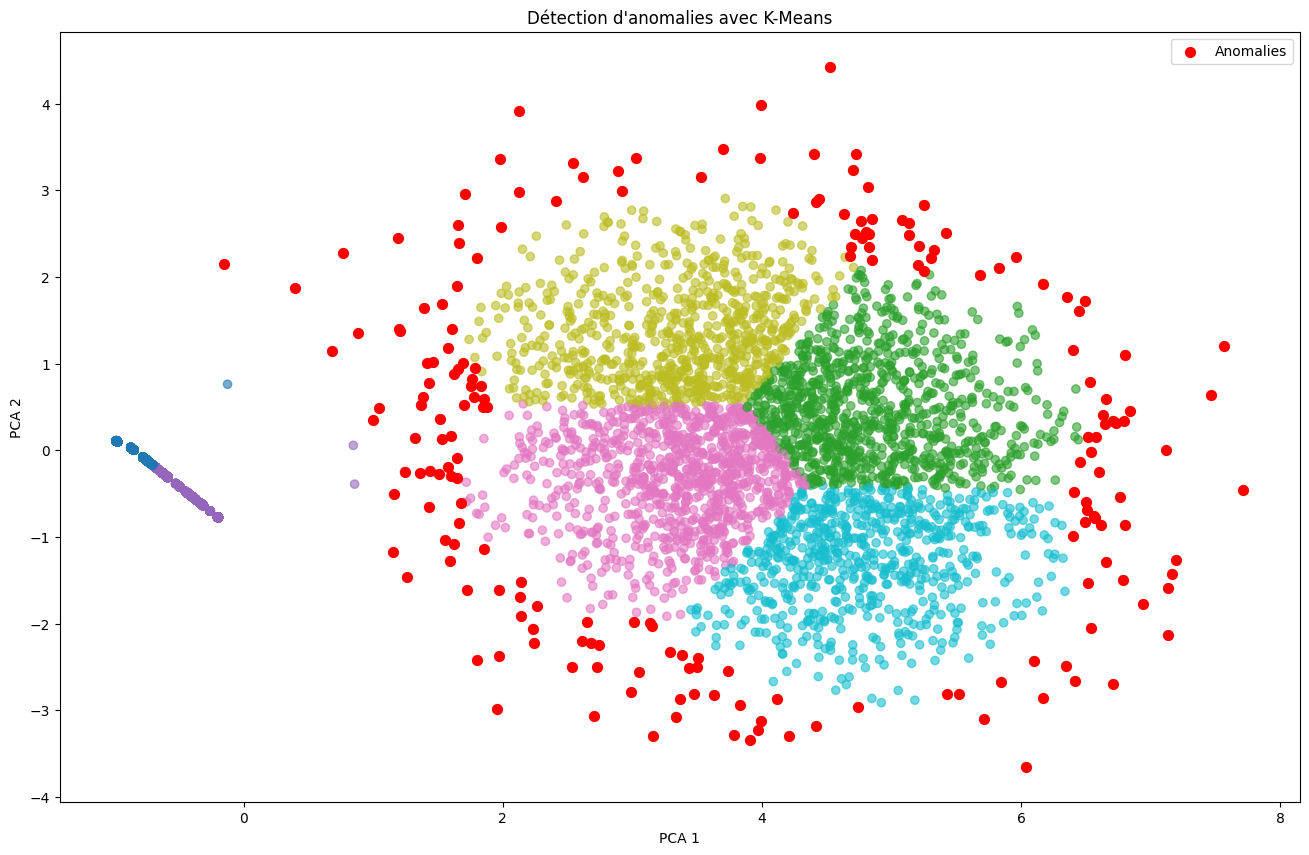

In [39]:


def main():

    df = load_data("transactions.csv")

    features = select_features(df)

    normalized_data = normalize_features(features)

    model, labels = apply_kmeans(
        normalized_data,
        n_clusters=6
    )

    distances = np.min(
        cdist(
            normalized_data,
            model.cluster_centers_
        ),
        axis=1
    )

    threshold = np.percentile(distances, 99)

    anomalies = detect_anomalies(
        normalized_data,
        model,
        threshold
    )

    print(f"Nombre d'anomalies : {len(anomalies)}")

    plot_clusters(
        normalized_data,
        labels,
        anomalies
    )
    
if __name__ == "__main__":
    main()

Étape 8 : Interprétation des résultats 